In [61]:
import numpy as np
import plotly.graph_objects as go
import fireducks.pandas as pd

import math as m
from sympy import symbols, Eq, solve, Rational
import pyomo.environ as pyo
from pyomo.environ import ConcreteModel, Var, Objective, Constraint, NonNegativeReals
from pyomo.opt import SolverFactory
import time


import subprocess


EXERCÍCIO PL: MBA PESQUISA OPERACIONAL

LUCAS EDUARDO SILVA BRAGA

# PROGRAMAÇAO LINEAR

A Programação Linear (PL) é uma técnica de otimização matemática utilizada para maximizar ou minimizar uma função objetivo sujeita a um conjunto de restrições lineares. Essa abordagem é amplamente aplicada em áreas como logística, produção, finanças e alocação de recursos, fornecendo soluções eficientes para problemas de tomada de decisão.

Neste relatório, resolvemos um problema de PL utilizando três abordagens distintas:

Método Gráfico: aplicamos a solução gráfica para visualizar a região factível e identificar a solução ótima. Esse método é útil para problemas com duas variáveis, permitindo uma interpretação geométrica da solução.
Resolução no Pyomo (Python): modelamos o problema utilizando o Pyomo, um framework para otimização matemática em Python, e utilizamos um solver para obter a solução numérica.
Resolução na linguagem Julia: utilizamos o pacote JuMP, que proporciona alto desempenho e flexibilidade para modelagem e solução de problemas de otimização.

## Solução pelo método gráfico



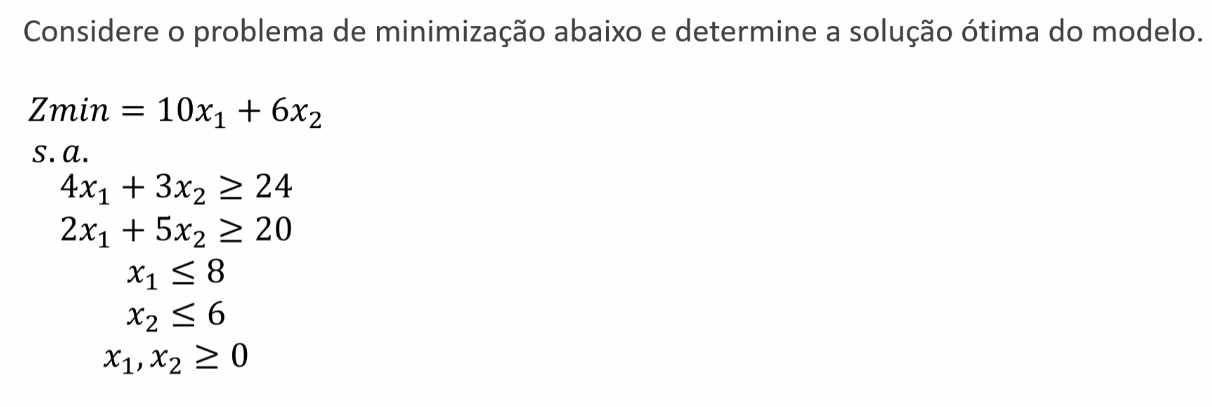

Primeiramente avaliamos qual é o objetivo do nosso modelo e traduzimos em uma Função Objetivo (FOB)

In [62]:
def FOB(x1,x2):
    return 10*x1 + 6*x2

Depois escrevemos as restrições do problema, que podem ser limites operacionais ou regras de negócio

In [63]:
x1_minimo = 0
x2_minimo = 0

x1_maximo = 8
x2_maximo = 6

In [64]:
# Funções das restrições
def restricao1(x1, x2):
    return 4*x1 + 3*x2 >= 24

def restricao2(x1, x2):
    return 2 *x1 + 5*x2 >= 20

def restricao3(x1):
    return x1 <= x1_maximo

def restricao4(x2):
    return x2 <= x2_maximo

# Funções de restrição reescritas para calcular x2 em função de x1
def calc_restricao1(x1):
    return (24 - 4 * x1) / 3

def calc_restricao2(x1):
    return (20 - 2 * x1) / 5

Definimos as variaveis e as equações das restrições

In [65]:
# Medindo o tempo de rodada
inicio = time.time()
# Definir as variáveis
x1, x2 = symbols('x1 x2')

# Definir as equações das restrições
eq1 = Eq(4*x1 + 3*x2, 24)  # R1: 4*x1 + 3*x2 = 24
eq2 = Eq(2*x1 + 5*x2, 20)  # R2: 2*x1 + 5*x2 = 20



### Calculo das interseções entre as restrições que delimitam uma área conhecida como região factível

In [66]:

# Calcular as interseções com os eixos e com as restrições

# 1. Interseção entre as duas retas que correspondem a esolver o sistema de equações R1 e R2
intersecao_R1_R2 = solve((eq1, eq2), (x1, x2))

#-----------------------------------------------------

# 2. Interseção da reta referente a restrição R1 com x1 = 0 (eixo x1)
intersecao_R1_x1_0 = solve(Eq(4*x1_minimo + 3*x2, 24), x2)

# 3. Interseção da reta referente a restrição R2 com x1 = 0 (eixo x1)
intersecao_R2_x1_0 = solve(Eq(2*x1_minimo + 5*x2, 20), x2)

# 4. Interseção da reta referente a restrição R1 com x1 = 8 (Limite Superior para x1)
intersecao_R1_x1_8 = solve(Eq(4*x1_maximo + 3*x2, 24), x2)

# 5. Interseção da reta referente a restrição R2 com x1 = 8 (Limite Superior para x1)
intersecao_R2_x1_8 = solve(Eq(2*x1_maximo + 5*x2, 20), x2)

#-----------------------------------------------------

# 6. Interseção da reta referente a R1 com x2 = 0 (eixo x2)
intersecao_R1_x2_0 = solve(Eq(4*x1 + 3*x2_minimo, 24), x1)

# 7. Interseção da reta referente a R2 com x2 = 0 (eixo x2)
intersecao_R2_x2_0 = solve(Eq(2*x1 + 5*x2_minimo, 20), x1)

# 8. Interseção da reta referente a R1 com x2 = 6
intersecao_R1_x2_6 = solve(Eq(4*x1 + 3*x2_maximo, 24), x1)

# 9. Interseção da reta referente a R2 com x2 = 6
intersecao_R2_x2_6 = solve(Eq(2*x1 + 5*x2_maximo, 20), x1)

#-----------------------------------------------------


### Validação dos vértices

In [67]:

def validar_vertices(vertices_calc):
    vertices_calc.append((x1_minimo,x1_minimo))
    vertices_calc.append((x1_maximo,x2_maximo))
    vertices_validos = []
    for (x1_value, x2_value) in vertices_calc:
        if restricao1(x1_value, x2_value) and restricao2(x1_value, x2_value) and restricao3(x1_value) and restricao4(x2_value):
            vertices_validos.append((x1_value, x2_value))
        else:
            continue
    return vertices_validos



# Armazenar os vértices possíveis
vertices = []

# Verificar se a interseção de R1 e R2 está dentro dos limites
if all(val.is_real for val in intersecao_R1_R2.values()):
    x1_val, x2_val = intersecao_R1_R2[x1], intersecao_R1_R2[x2]
    if x1_minimo <= x1_val <= x1_maximo and x2_minimo <= x2_val <= x2_maximo:
        vertices.append((x1_val, x2_val))


# Verificar se a interseção de R1 com x1 = 0 está dentro dos limites
if x2_minimo <= intersecao_R1_x1_0[0] <= x2_maximo:
    vertices.append((x1_minimo, intersecao_R1_x1_0[0]))

# Verificar se a interseção de R1 com x1 = 8 está dentro dos limites
if x2_minimo <= intersecao_R1_x1_8[0] <= x2_maximo:
    vertices.append((x1_maximo, intersecao_R1_x1_8[0]))


# Verificar se a interseção de R2 com x1 = 0 está dentro dos limites
if x2_minimo <= intersecao_R2_x1_0[0] <= x2_maximo:
    vertices.append((x1_minimo, intersecao_R2_x1_0[0]))

# Verificar se a interseção de R2 com x1 = 8 está dentro dos limites
if x2_minimo <= intersecao_R2_x1_8[0] <= x2_maximo:
    vertices.append((x1_maximo, intersecao_R2_x1_8[0]))



# Verificar se a interseção de R1 com x2 = 0 está dentro dos limites
if x1_minimo <= intersecao_R1_x2_0[0] <= x1_maximo:
    vertices.append((intersecao_R1_x2_0[0], x2_minimo))

# Verificar se a interseção de R1 com x2 = 6 está dentro dos limites
if x1_minimo <= intersecao_R1_x2_6[0] <= x1_maximo:
    vertices.append((intersecao_R1_x2_6[0], x2_maximo))


# Verificar se a interseção de R2 com x2 = 6 está dentro dos limites
if x1_minimo <= intersecao_R2_x2_0[0] <= x1_maximo:
    vertices.append((intersecao_R2_x2_0[0], x2_minimo))

# Verificar se a interseção de R2 com x1 = 8 está dentro dos limites
if x1_minimo <= intersecao_R2_x2_6[0] <= x1_maximo:
    vertices.append((intersecao_R2_x2_6[0], x2_maximo))



vertices = [(x.evalf() if isinstance(x, Rational) else x, 
               y.evalf() if isinstance(y, Rational) else y) 
            for x, y in vertices]


# Garantir que os valores estão em formato float
valid_vertices_float = [(float(x), float(y)) for x, y in vertices]

valid_vertices =  validar_vertices(valid_vertices_float)
# Exibir os vértices válidos
print("Vértices da região factível:")
print(valid_vertices)

Vértices da região factível:
[(4.285714285714286, 2.2857142857142856), (8.0, 0.8), (1.5, 6.0), (8, 6)]


### Plotar Gráfico

In [68]:
# Definir a faixa de valores de x1 para o gráfico
x1_vals = np.linspace(0, 10, 400)

# Criar o gráfico com Plotly
fig = go.Figure()

# Plotando as restrições
fig.add_trace(go.Scatter(x=x1_vals, y=calc_restricao1(x1_vals), mode='lines', name=r'$4x_1 + 3x_2 \leq 24$', line=dict(color='blue')))
fig.add_trace(go.Scatter(x=x1_vals, y=calc_restricao2(x1_vals), mode='lines', name=r'$2x_1 + 5x_2 \leq 20$', line=dict(color='green')))

# Adicionando as restrições de x1 e x2 (linhas verticais e horizontais)
fig.add_trace(go.Scatter(x=[8, 8], y=[0, 6], mode='lines', name=r'$x_1 \leq 8$', line=dict(color='red', dash='dash')))
fig.add_trace(go.Scatter(x=[0, 8], y=[6, 6], mode='lines', name=r'$x_2 \leq 6$', line=dict(color='purple', dash='dash')))

# Plotando os vértices da região factível
fig.add_trace(go.Scatter(x=[x[0] for x in valid_vertices], 
                         y=[x[1] for x in valid_vertices], 
                         mode='markers', name='Vértices', 
                         marker=dict(color='black', size=10)))



# Definir o layout do gráfico e ativar a grade
fig.update_layout(
    title='Gráfico de Programação Linear - Região Factível e Vértices',
    xaxis_title=r'x_1',
    yaxis_title=r'x_2',
    xaxis=dict(
        range=[0, 10],
        showgrid=True,  # Ativar a grade para o eixo x
        gridcolor='gray',  # Cor da grade
        gridwidth=0.5  # Espessura da linha da grade
    ),
    yaxis=dict(
        range=[0, 10],
        showgrid=True,  # Ativar a grade para o eixo y
        gridcolor='gray',  # Cor da grade
        gridwidth=0.5  # Espessura da linha da grade
    ),
    showlegend=True,
    plot_bgcolor='white'
)
# Mostrar o gráfico
fig.show()

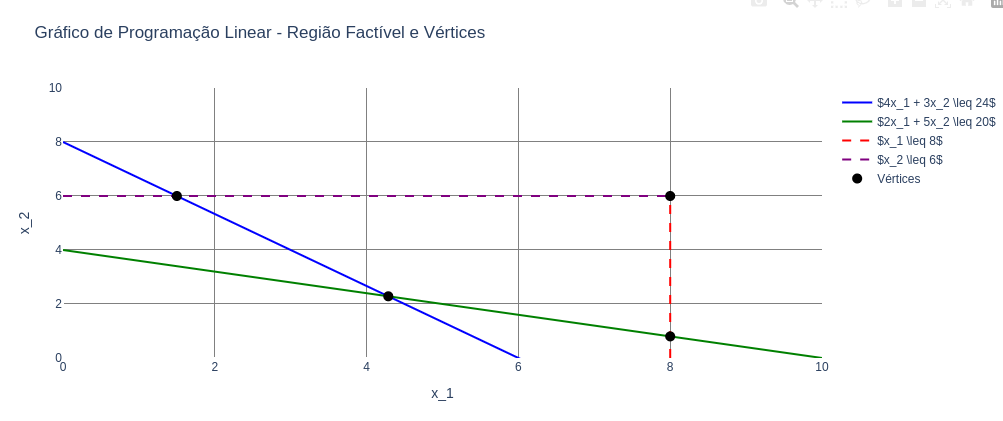

In [69]:
FOB_solucoes = {"FOB":[],"x1":[],"x2":[]}

for x1, x2 in valid_vertices:
    # Adicionando valores na lista correspondente
    FOB_solucoes["FOB"].append(FOB(x1, x2))
    FOB_solucoes["x1"].append(x1)
    FOB_solucoes["x2"].append(x2)

# Encontrando o índice do menor valor de FOB
indice_max_FOB = FOB_solucoes["FOB"].index(min(FOB_solucoes["FOB"]))
fim = time.time()

# Calculando o tempo de execução
tempo_execucao = fim - inicio

# Pegando os valores correspondentes de x1 e x2
x1_otimo = FOB_solucoes["x1"][indice_max_FOB]
x2_otimo = FOB_solucoes["x2"][indice_max_FOB]
FOB_otimo = FOB_solucoes["FOB"][indice_max_FOB]

# Montando o vetor resultado_otimo
resultado_otimo = [FOB_otimo, x1_otimo, x2_otimo]

# Exibindo o vetor resultado_otimo
print(f"Resultado ótimo: {resultado_otimo}")
print("RELATORIO")
print('-'*50)

print(f'Tempo de Rodada: {tempo_execucao}')


print('-'*50)

df_result_grafico = pd.DataFrame(FOB_solucoes)
df_result_grafico

Resultado ótimo: [51.0, 1.5, 6.0]
RELATORIO
--------------------------------------------------
Tempo de Rodada: 0.18538975715637207
--------------------------------------------------


,FOB,x1,x2
0,56.571429,4.285714,2.285714
1,84.800000,8.000000,0.800000
2,51.000000,1.500000,6.000000
3,116.000000,8.000000,6.000000


## Solução de PL via Pyomo

### Criação do Modelo

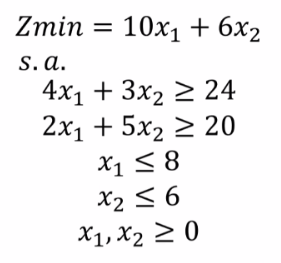

In [70]:
# Modelo de Programação Linear com Pyomo


# Função para contar as chamadas à função objetivo
class ObjectiveCounter:
    def __init__(self):
        self.count = 0
        
    def __call__(self, model):
        self.count += 1
        return FOB(model.x1, model.x2)


# Medindo o tempo de rodada
inicio = time.time()

model = pyo.ConcreteModel()

### Modelagem do Problema

In [71]:
# Variáveis de decisão
model.x1 = pyo.Var(within=pyo.NonNegativeReals)  # x1 >= 0
model.x2 = pyo.Var(within=pyo.NonNegativeReals)  # x2 >= 0

# Função objetivo
contador_objetivo = ObjectiveCounter()
model.obj = pyo.Objective(expr=contador_objetivo, sense=pyo.minimize)

# Restrições
model.restricao1 = pyo.Constraint(expr=restricao1(model.x1,model.x2))  # 4x1 + 3x2 = 24
model.restricao2 = pyo.Constraint(expr=restricao2(model.x1,model.x2))  # 2x1 + 5x2 = 20
model.restricao3 = pyo.Constraint(expr=restricao3(model.x1))  # x1 <= 8
model.restricao4 = pyo.Constraint(expr=restricao4(model.x2))  # x2 <= 6


### Resolvendo o Modelo Matemático

In [72]:
# Solucionando o modelo com o solver GLPK
opt = SolverFactory('glpk')
result = opt.solve(model, tee=False)
fim = time.time()

# Calculando o tempo de execução
tempo_execucao = fim - inicio
# Obtendo o número de chamadas à função objetivo
num_funcoes_avaliadas = contador_objetivo.count

# Exibindo os resultados
print(f"Status da solução: {result.solver.status}")
print(f"Valor ótimo da função objetivo: {pyo.value(model.obj)}")
print(f"Valor ótimo de x1: {pyo.value(model.x1)}")
print(f"Valor ótimo de x2: {pyo.value(model.x2)}")

print('-'*50)

print(f'Tempo de Rodada: {tempo_execucao}')
print(f'num_funcoes_avaliadas: {num_funcoes_avaliadas}')

print('-'*50)
df_result_grafico


Status da solução: ok
Valor ótimo da função objetivo: 51.0
Valor ótimo de x1: 1.5
Valor ótimo de x2: 6.0
--------------------------------------------------
Tempo de Rodada: 0.10237479209899902
num_funcoes_avaliadas: 1
--------------------------------------------------


,FOB,x1,x2
0,56.571429,4.285714,2.285714
1,84.800000,8.000000,0.800000
2,51.000000,1.500000,6.000000
3,116.000000,8.000000,6.000000


## Solução de PL via julia

In [73]:
# Definindo o caminho para o script Julia
julia_script = "PL_ex01.jl"
# Executando o script Julia usando subprocess
try:
    subprocess.run(["julia", julia_script], check=True)
except subprocess.CalledProcessError as e:
    print(f"Ocorreu um erro ao executar o script Julia: {e}")

print('-'*50)
df_result_grafico

Min 10 x[1] + 6 x[2]
Subject to
 4 x[1] + 3 x[2] ≥ 24
 2 x[1] + 5 x[2] ≥ 20
 x[1] ≤ 8
 x[2] ≤ 6
 x[1] ≥ 0
 x[2] ≥ 0
--------------------------------------------------
 X* = [1.5000000000000002, 6.0]
--------------------------------------------------
 FOB = 51.0
 FOB_status = OPTIMAL
--------------------------------------------------
Tempo de Rodada = 4.601392835
num_funcoes_avaliadas = 1
--------------------------------------------------


,FOB,x1,x2
0,56.571429,4.285714,2.285714
1,84.800000,8.000000,0.800000
2,51.000000,1.500000,6.000000
3,116.000000,8.000000,6.000000
